# PCA_LDA_KernelPCA_COMPARISON

In [ ]:
# dataset link
# https://www.kaggle.com/datasets/hrdkcodes/wine-data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

dataset = pd.read_csv('Wine.csv')
X = dataset.iloc[:, :-1].to_numpy()
y = dataset.iloc[:, -1].to_numpy()

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [45]:
pca = PCA(n_components = 2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)



lda = LDA(n_components = 2)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)



kpca = KernelPCA(n_components = 2, kernel = 'rbf')
X_train_kpca = kpca.fit_transform(X_train)
X_test_kpca = kpca.transform(X_test)

In [46]:
def evaluate_and_plot(X_train_dim, y_train, title):

    classifier = LogisticRegression(random_state = 0)
    classifier.fit(X_train_dim, y_train)

    cmap = ListedColormap(('red', 'green', 'blue'))
    X1, X2 = np.meshgrid(np.arange(X_train_dim[:, 0].min() - 1, X_train_dim[:, 0].max() + 1, 0.01),
                         np.arange(X_train_dim[:, 1].min() - 1, X_train_dim[:, 1].max() + 1, 0.01))
    
    plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                 alpha = 0.5, cmap = cmap)
    
    for i, j in enumerate(np.unique(y_train)):
        plt.scatter(X_train_dim[y_train == j, 0], X_train_dim[y_train == j, 1],
                    c = [cmap(i)], label = j, s=30)
    
    plt.title(f"{title}")
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.legend()
    plt.show()

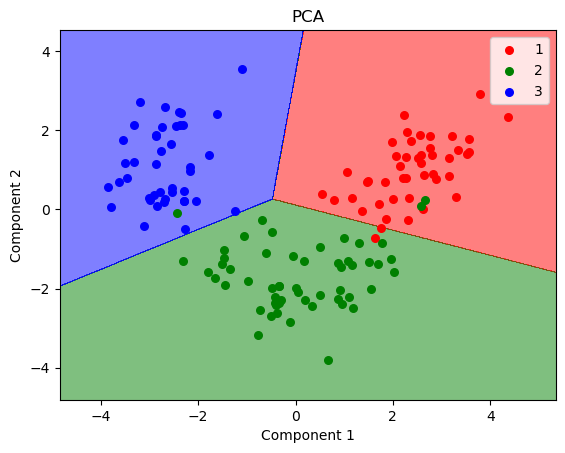

In [47]:
evaluate_and_plot(X_train_pca, y_train, 'PCA')

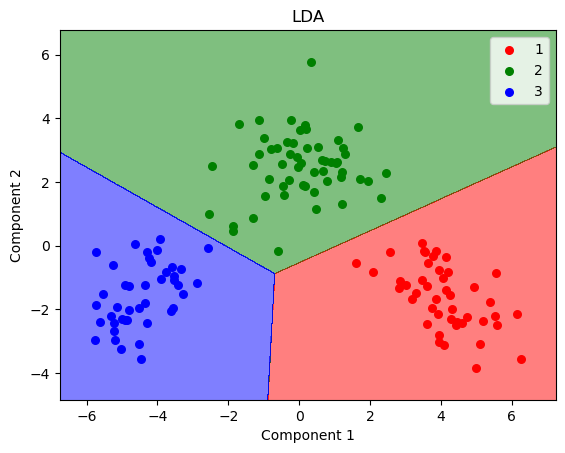

In [48]:
evaluate_and_plot(X_train_lda, y_train, 'LDA')

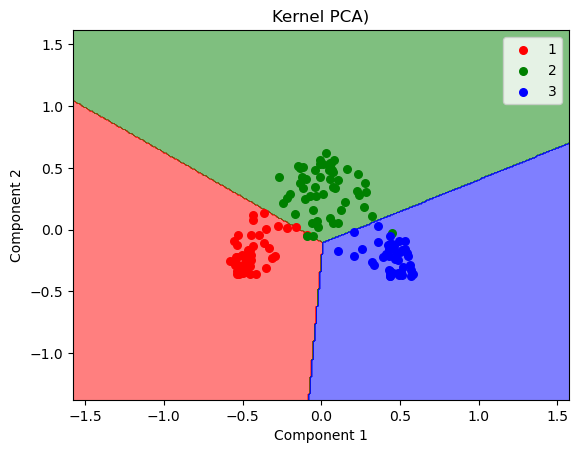

In [49]:
evaluate_and_plot(X_train_kpca, y_train, 'Kernel PCA)')